In [35]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# Load Datasets
fund_score = pd.read_csv("../data/processed/fund_scorecard.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [37]:
# Convert Date Columns
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [38]:
# Select Top 5 Funds
top5 = fund_score.sort_values("Overall_Rank").head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[148567, 120505, 120843, 100033, 120504]


In [39]:
# Keep Last 3 Years Data
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav = nav[nav["date"] >= start_date]

benchmark = benchmark[benchmark["date"] >= start_date]

In [40]:
# Filter Top 5 Funds
fund_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

In [41]:
# Calculate Fund Daily Returns
fund_nav = fund_nav.sort_values(["amfi_code","date"])

fund_nav["fund_return"] = (
    fund_nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [42]:
# Prepare Benchmarks
benchmark = benchmark[
    benchmark["index_name"].isin(["NIFTY50","NIFTY100"])
].copy()

benchmark = benchmark.sort_values(["index_name","date"])

benchmark["benchmark_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

In [43]:
# Normalize Values for Comparison Chart
fund_plot = fund_nav.copy()

fund_plot["Normalized_NAV"] = (
    fund_plot
    .groupby("amfi_code")["nav"]
    .transform(lambda x: x/x.iloc[0]*100)
)

benchmark["Normalized_Index"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .transform(lambda x: x/x.iloc[0]*100)
)

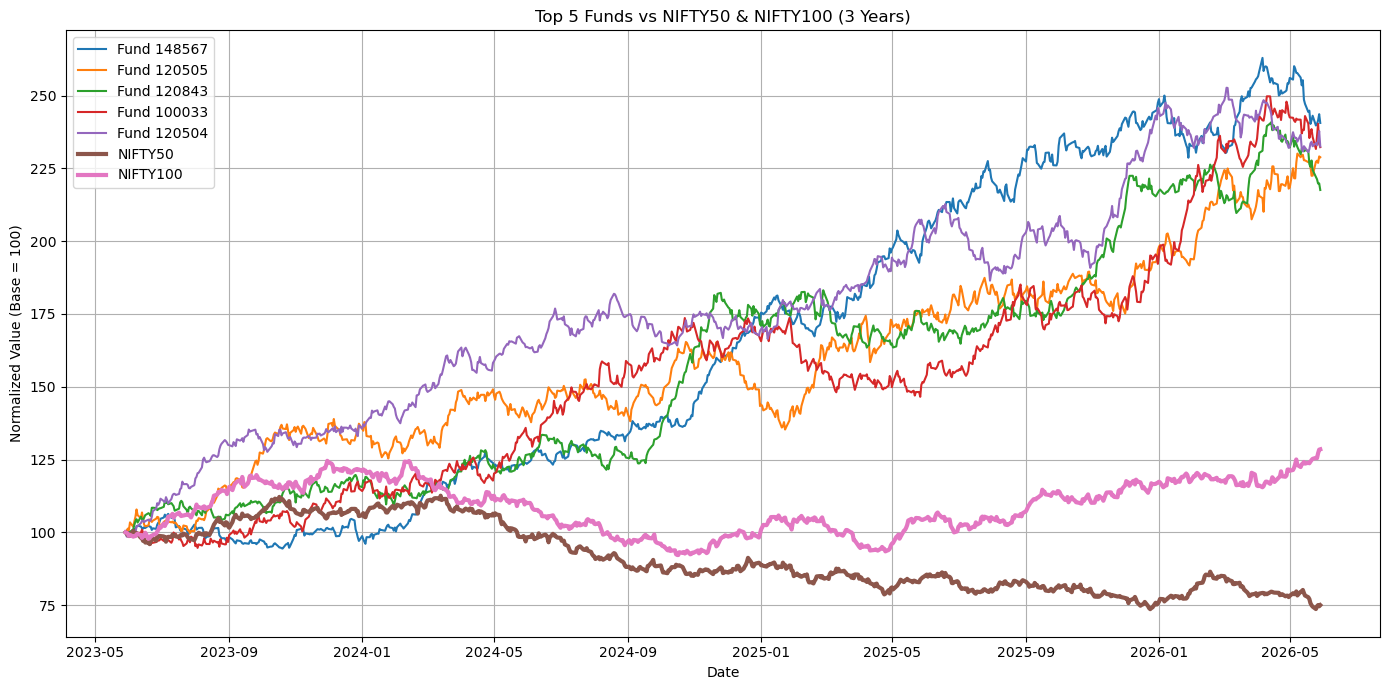

In [50]:
# Plot Comparison
plt.figure(figsize=(14, 7))

# Plot Top 5 Funds
for code in top5_codes:
    temp = fund_plot[fund_plot["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=f"Fund {code}"
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[benchmark["index_name"] == idx]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/22_benchmark_comparison.png")

plt.show()


In [51]:
# Tracking Error
tracking_results = []

for code in top5_codes:

    fund = fund_nav[
        ["date","amfi_code","fund_return"]
    ]

    fund = fund[fund["amfi_code"]==code]

    for benchmark_name in ["NIFTY50","NIFTY100"]:

        bm = benchmark[
            benchmark["index_name"]==benchmark_name
        ][["date","benchmark_return"]]

        merged = pd.merge(
            fund,
            bm,
            on="date",
            how="inner"
        )

        merged = merged.dropna()

        tracking_error = (
            (
                merged["fund_return"]
                -
                merged["benchmark_return"]
            ).std()
        ) * np.sqrt(252)

        tracking_results.append({
            "amfi_code":code,
            "Benchmark":benchmark_name,
            "Tracking_Error":tracking_error
        })

tracking_df = pd.DataFrame(tracking_results)

print(tracking_df)

   amfi_code Benchmark  Tracking_Error
0     148567   NIFTY50        0.191868
1     148567  NIFTY100        0.187974
2     120505   NIFTY50        0.228447
3     120505  NIFTY100        0.232661
4     120843   NIFTY50        0.205067
5     120843  NIFTY100        0.206540
6     100033   NIFTY50        0.228222
7     100033  NIFTY100        0.224976
8     120504   NIFTY50        0.188211
9     120504  NIFTY100        0.187299


In [52]:
# Save CSV
tracking_df.to_csv(
    "../data/processed/tracking_error_analysis.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!


In [47]:
## Insight

# The benchmark comparison chart shows how the top five mutual funds performed against the NIFTY50 and NIFTY100 indices over the last three years. Tracking Error measures how closely each fund follows its benchmark; a lower tracking error indicates performance more closely aligned with the benchmark, while a higher value reflects greater deviation.